In [1]:
pip install pytorch-tabnet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ============================================================================
# TABNET — FINE-TUNING DÉTECTION TRANSACTIONS SUSPECTES
# ============================================================================
import pandas as pd
import numpy as np
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import torch

print("=" * 60)
print("TABNET — DÉTECTION TRANSACTIONS SUSPECTES")
print("=" * 60)



TABNET — DÉTECTION TRANSACTIONS SUSPECTES


In [5]:
# ============================================================================
# 1. CHARGEMENT ET PRÉPARATION
# ============================================================================
features   = pd.read_excel(r"C:\Users\Pc\Desktop\new\features_comptes.xlsx")
operations = pd.read_excel(r"C:\Users\Pc\Desktop\new\opérations comptes.xls")

# Labels par compte
operations['compte'] = operations['compte'].astype(str)
labels = operations.groupby('compte')['anomalie'].max().reset_index()
labels.columns = ['compte', 'anomalie']

# Fusion
features['compte'] = features['compte'].astype(str)
df = features.merge(labels, on='compte', how='inner')
print(f"Dataset fusionné : {df.shape}")
print(f"Anomalies : {df['anomalie'].sum()} / {len(df)}")

Dataset fusionné : (2838, 28)
Anomalies : 320.0 / 2838


In [6]:
# ============================================================================
# 2. PRÉPARATION FEATURES
# ============================================================================
cols_exclude = ['compte', 'lieu_principal', 'anomalie']
feature_cols = [c for c in df.columns if c not in cols_exclude]

X_all = df[feature_cols].copy()
y     = df['anomalie'].values.astype(int)

# Nettoyage
X_all = X_all.replace([np.inf, -np.inf], np.nan)
X_all = X_all.fillna(X_all.median())

# Dataset final
X = X_all.values

print(f"\n✅ Features utilisées pour TabNet : {len(feature_cols)}")
print(f"   {feature_cols}")


✅ Features utilisées pour TabNet : 25
   ['nb_transactions', 'total_montant', 'montant_moyen', 'montant_median', 'montant_std', 'montant_min', 'montant_max', 'duree_activite_jours', 'ratio_max_moyen', 'nb_transactions_mois', 'pct_nocturne', 'pct_weekend', 'nb_lieux_differents', 'pct_lieu_principal', 'changements_lieu_frequents', 'temps_moyen_entre_tx_min', 'temps_median_entre_tx_min', 'temps_min_entre_tx_min', 'temps_std_entre_tx_min', 'montants_croissants_consecutifs', 'ratio_montant_max_min', 'velocite_maximale_km_h', 'nb_tpe_moins_100', 'ratio_tpe_moins_100', 'tx_par_jour']


In [7]:
# ============================================================================
# 3. TRAIN / VALID / TEST SPLIT
# ============================================================================
# Split stratifié pour respecter la proportion anomalies
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y#même proportion d’anomalies dans train et test
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print(f"\nTrain : {X_train.shape[0]} | Valid : {X_valid.shape[0]} | Test : {X_test.shape[0]}")#Valid → contrôler / ajuster!!
print(f"Anomalies train : {y_train.sum()} | valid : {y_valid.sum()} | test : {y_test.sum()}")


Train : 1929 | Valid : 341 | Test : 568
Anomalies train : 218 | valid : 38 | test : 64


In [8]:
# ============================================================================
# 4. NORMALISATION
# ============================================================================
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)
X_test_s  = scaler.transform(X_test)

In [9]:
# ============================================================================
# 5. GESTION DU DÉSÉQUILIBRE DES CLASSES
# ============================================================================
# Poids inversement proportionnels à la fréquence
n_normal = (y_train == 0).sum()
n_anomal = (y_train == 1).sum()
ratio    = n_normal / n_anomal

print(f"\nRatio déséquilibre : {ratio:.1f}x")
print(f"→ weight classe anomalie = {ratio:.1f}")


Ratio déséquilibre : 7.8x
→ weight classe anomalie = 7.8


In [10]:
# ============================================================================
# 6. CONFIGURATION TABNET (FINE-TUNING)
# ============================================================================
# Paramètres adaptés à un petit dataset (2838 échantillons)
clf = TabNetClassifier(

    # --- Architecture ---
    n_d=16,
    n_a=16,
    n_steps=4,
    gamma=1.3,

    # --- Régularisation ---
    lambda_sparse=1e-3,
    momentum=0.02,
    epsilon=1e-15,

    # --- Optimiseur ---
    optimizer_fn=torch.optim.Adam,
    optimizer_params={"lr": 2e-3, "weight_decay": 1e-5},

    # --- Scheduler ---
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={"step_size": 10, "gamma": 0.9},

    # --- Reproductibilité ---
    seed=42,
    verbose=1,
    device_name='cpu'
)

c:\Users\Pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [11]:
# ============================================================================
# 7. ENTRAÎNEMENT (FINE-TUNING)
# ============================================================================
print("\n" + "="*60)
print("ENTRAÎNEMENT TABNET")
print("="*60)

clf.fit(
    X_train=X_train_s,
    y_train=y_train,

    eval_set=[(X_valid_s, y_valid)],
    eval_name=["valid"],
    eval_metric=["auc"],          # métrique de validation

    max_epochs=20,               # nb max d'époques
    patience=10,                  # early stopping si pas d'amélioration
    batch_size=64,               # petit batch pour petit dataset
    virtual_batch_size=32,        # ghost batch normalization

    # Poids classes déséquilibrées
    weights={0: 1, 1: int(ratio)}
)


ENTRAÎNEMENT TABNET
epoch 0  | loss: 0.89982 | valid_auc: 0.5865  |  0:00:01s
epoch 1  | loss: 0.67624 | valid_auc: 0.82534 |  0:00:01s
epoch 2  | loss: 0.59821 | valid_auc: 0.87841 |  0:00:02s
epoch 3  | loss: 0.56556 | valid_auc: 0.8316  |  0:00:03s
epoch 4  | loss: 0.55069 | valid_auc: 0.90429 |  0:00:04s
epoch 5  | loss: 0.50113 | valid_auc: 0.9346  |  0:00:06s
epoch 6  | loss: 0.43792 | valid_auc: 0.93964 |  0:00:07s
epoch 7  | loss: 0.38226 | valid_auc: 0.96335 |  0:00:08s
epoch 8  | loss: 0.38444 | valid_auc: 0.98628 |  0:00:09s
epoch 9  | loss: 0.32633 | valid_auc: 0.97968 |  0:00:10s
epoch 10 | loss: 0.34728 | valid_auc: 0.95657 |  0:00:11s
epoch 11 | loss: 0.28051 | valid_auc: 0.96526 |  0:00:11s
epoch 12 | loss: 0.30678 | valid_auc: 0.97672 |  0:00:12s
epoch 13 | loss: 0.31312 | valid_auc: 0.97507 |  0:00:13s
epoch 14 | loss: 0.28841 | valid_auc: 0.96196 |  0:00:14s
epoch 15 | loss: 0.28822 | valid_auc: 0.97646 |  0:00:14s
epoch 16 | loss: 0.24118 | valid_auc: 0.98723 |  0:

c:\Users\Pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [12]:
# ============================================================================
# 8. ÉVALUATION
# ============================================================================
print("\n" + "="*60)
print("ÉVALUATION SUR TEST")
print("="*60)

y_pred      = clf.predict(X_test_s)
y_proba     = clf.predict_proba(X_test_s)[:, 1]

roc_auc  = roc_auc_score(y_test, y_proba)
f1       = f1_score(y_test, y_pred)

print(f"\nROC AUC  : {roc_auc:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"\nRapport de classification :")
print(classification_report(y_test, y_pred,
                             target_names=["Normal", "Anomalie"]))


ÉVALUATION SUR TEST

ROC AUC  : 0.9631
F1 Score : 0.8421

Rapport de classification :
              precision    recall  f1-score   support

      Normal       0.98      0.97      0.98       504
    Anomalie       0.81      0.88      0.84        64

    accuracy                           0.96       568
   macro avg       0.90      0.92      0.91       568
weighted avg       0.96      0.96      0.96       568



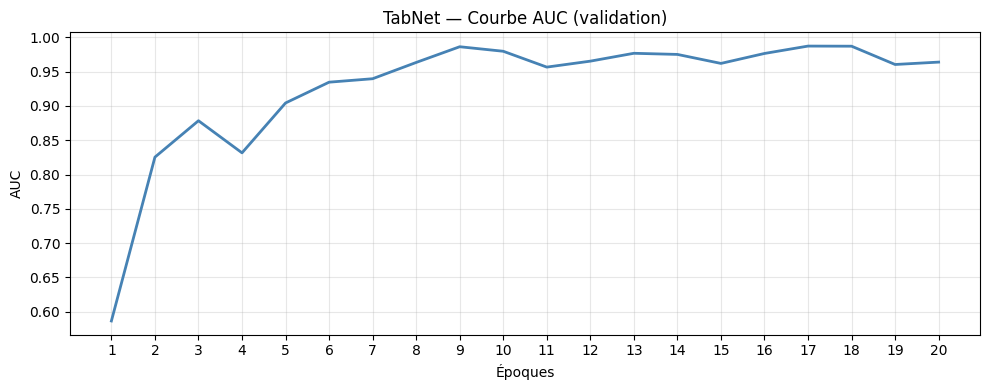

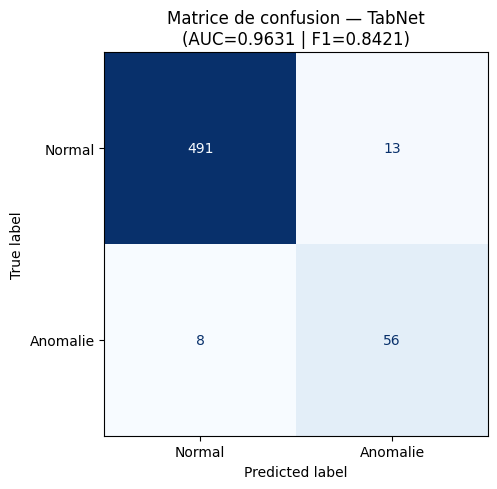

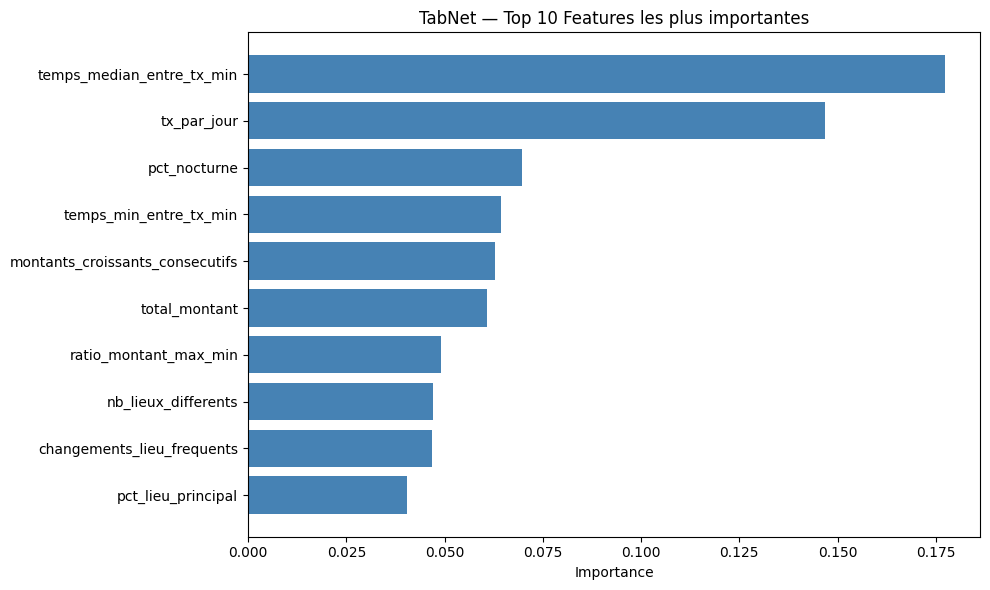


Top 10 features :
                        Feature  Importance
      temps_median_entre_tx_min    0.177373
                    tx_par_jour    0.146749
                   pct_nocturne    0.069751
         temps_min_entre_tx_min    0.064237
montants_croissants_consecutifs    0.062733
                  total_montant    0.060873
          ratio_montant_max_min    0.049064
            nb_lieux_differents    0.046957
     changements_lieu_frequents    0.046823
             pct_lieu_principal    0.040326

SCORES FINAUX — TABNET
ROC AUC  : 0.9631
F1 Score : 0.8421
Époques  : 20
Features : 25


In [13]:
# ============================================================================
# 9. VISUALISATIONS
# ============================================================================

# --- Courbe AUC pendant l'entraînement ---
plt.figure(figsize=(10, 4))
auc_values = clf.history['valid_auc']
epochs = range(1, len(auc_values) + 1)  # commence à 1
plt.plot(epochs, auc_values, linewidth=2, color='steelblue')
plt.xlabel("Époques")
plt.ylabel("AUC")
plt.title("TabNet — Courbe AUC (validation)")
plt.xticks(range(1, len(auc_values) + 1))  # force 1,2,3,...,20
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# --- Matrice de confusion ---
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomalie"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matrice de confusion — TabNet\n(AUC={roc_auc:.4f} | F1={f1:.4f})")
plt.tight_layout(); plt.show()

# --- Importance des features (SHAP-like de TabNet) ---
feat_importance = clf.feature_importances_
feat_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Importance' : feat_importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'][:10], feat_df['Importance'][:10],
         color='steelblue')
plt.xlabel("Importance")
plt.title("TabNet — Top 10 Features les plus importantes")
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

print("\nTop 10 features :")
print(feat_df.head(10).to_string(index=False))

# ============================================================================
# 10. SCORES FINAUX
# ============================================================================
print("\n" + "="*60)
print("SCORES FINAUX — TABNET")
print("="*60)
print(f"ROC AUC  : {roc_auc:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"Époques  : {len(clf.history['valid_auc'])}")
print(f"Features : {len(feature_cols)}")